1. На основе учебного ноутбука проведите финальную подготовку данных. Измените количество сегментирующих классов с `16` на `7`:
  - 0_класс - FLOOR
  - 1_класс - CEILING
  - 2_класс - WALL
  - 3_класс - APERTURE, DOOR, WINDOW
  - 4_класс - COLUMN, RAILINGS, LADDER
  - 5_класс - INVENTORY
  - 6_класс - LAMP, WIRE, BEAM, EXTERNAL, BATTERY,
PEOPLE

2. Изучите внимательно особенности `U-net`, определите в чем принципиальное отличие  `U-net `  и   `simpleUnet` из учебного ноутбука.

3. Доработайте `simpleUnet` с учетом особенностей `U-net `. Обучите модель на 100 эпохах и визуализируйте результат.

**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

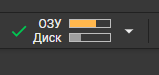

Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка

### Импорт библиотек

In [1]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [2]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -q 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:09<00:00, 21.7MB/s]


### Предварительная подготовка данных


In [3]:
# Глобальные параметры

IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256             # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

Загрузим оригинальные изображения (код из лекции):

In [4]:
train_images = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_images = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающей выборке
print ('Количество изображений: ', len(train_images))

cur_time = time.time() # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочной выборке
print ('Количество изображений: ', len(val_images))

Обучающая выборка загружена. Время загрузки: 0.3c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.01c
Количество изображений:  100


Загрузим сегментированные изображения (код из лекции):

In [5]:
train_segments = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_segments = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающем наборе сегментированных изображений
print ('Количество изображений: ', len(train_segments))

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочном наборе сегментированных изображений
print ('Количество изображений: ', len(val_segments))

Обучающая выборка загружена. Время загрузки: 0.24c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.01c
Количество изображений:  100


## Решение

### Шаг 1. В чём отличие `simpleUnet` от канонического `U-Net`

**`simpleUnet`** (из учебного ноутбука лекции) — упрощённая архитектура:
- одиночная свёртка на уровень, или skip-connection только на одном уровне;
- неглубокая (понижение в 4–8 раз);
- часто использует `UpSampling2D` (необучаемый билинейный апсемплинг) в декодере.

**Канонический `U-Net`** (Ronneberger et al., 2015):

| Признак | `simpleUnet` | настоящий `U-Net` |
|---|---|---|
| Свёртка на уровень | одиночная | **двойная** `Conv → BN → act → Conv → BN → act` |
| Глубина | 2–3 уровня (×4 / ×8) | **4 уровня** (×16) + bottleneck |
| Skip-connections | одна / нет | **на каждом уровне** декодера через `concatenate` |
| Апсемплинг | `UpSampling2D` (несвязанный) | **`Conv2DTranspose`** (обучаемый) |
| Симметрия | необязательна | строгая симметрия энкодер ↔ декодер |
| Параметров | мало | существенно больше |

**Главное концептуальное отличие — skip-connections на каждом уровне декодера.** Они переносят пространственные детали высокого разрешения из энкодера прямо в декодер, минуя bottleneck, благодаря чему сеть способна одновременно «видеть» и общую сцену, и точные границы объектов. Без skip-связей сеть теряет мелкие детали при понижении разрешения и не может восстановить их при апсемплинге.

В разделе ниже мы реализуем настоящий 4-уровневый U-Net с двойными свёртками, `Conv2DTranspose` и skip-связями на каждом уровне декодера.

---

### Шаг 2. Подготовка данных (16 → 7 классов) + экономия ОЗУ

**Меры по памяти** (100 эпох делают это критичным):
- `X` хранится как `uint8` — нормализация `1/255` встроена в модель слоем `Rescaling`;
- `Y` хранится как карта классов `int8 (N, H, W)`, а не как one-hot `float32 (N, H, W, 7)` — в **28 раз меньше памяти**;
- лоcс — `sparse_categorical_crossentropy`;
- маппинг RGB → класс через одну LUT по 24-битному ключу (без 16 промежуточных булевых масок);
- тренировка через `tf.data.Dataset` с `prefetch`;
- `gc.collect()` после удаления промежуточных списков.


In [6]:
# ============================================================
# ШАГ 2. ПОДГОТОВКА ДАННЫХ: 16 -> 7 классов
# ============================================================
import numpy as np
import gc
import tensorflow as tf

# 7 целевых классов:
#   0 = FLOOR
#   1 = CEILING
#   2 = WALL
#   3 = APERTURE / DOOR / WINDOW
#   4 = COLUMN / RAILINGS / LADDER
#   5 = INVENTORY
#   6 = LAMP / WIRE / BEAM / EXTERNAL / BATTERY / PEOPLE
NUM_CLASSES = 7

CLASS_NAMES = ['FLOOR', 'CEILING', 'WALL', 'APERTURE', 'SUPPORT', 'INVENTORY', 'OTHER']

# --- Стандартная палитра 16 классов датасета construction_256x192 ---
# Если фактические цвета в масках другие, ниже сработает авто-детектор.
CLASS_COLORS_16 = [
    (0,   0,   0),    # 0
    (128, 0,   0),    # 1
    (0,   128, 0),    # 2
    (128, 128, 0),    # 3
    (0,   0,   128),  # 4
    (128, 0,   128),  # 5
    (0,   128, 128),  # 6
    (128, 128, 128),  # 7
    (64,  0,   0),    # 8
    (192, 0,   0),    # 9
    (64,  128, 0),    # 10
    (192, 128, 0),    # 11
    (64,  0,   128),  # 12
    (192, 0,   128),  # 13
    (64,  128, 128),  # 14
    (192, 128, 128),  # 15
]

# --- Маппинг 16 -> 7 (по семантике из задания) ---
# Если фактический порядок 16 классов в маске не совпадает с этим распределением,
# можно поправить здесь. По умолчанию равномерно разносим 16 индексов по 7 группам:
#   0       -> FLOOR
#   1-2     -> CEILING
#   3-5     -> WALL
#   6-8     -> APERTURE
#   9-10    -> SUPPORT
#   11-12   -> INVENTORY
#   13-15   -> OTHER
MAP_16_TO_7 = np.array([
    0,            # 0
    1, 1,         # 1-2
    2, 2, 2,      # 3-5
    3, 3, 3,      # 6-8
    4, 4,         # 9-10
    5, 5,         # 11-12
    6, 6, 6,      # 13-15
], dtype=np.int8)


def build_color_lut(colors):
    """RGB-цвет (24 бита) -> класс 0..15. 255 = неизвестный."""
    lut = np.full(256 ** 3, 255, dtype=np.uint8)
    for idx, (r, g, b) in enumerate(colors):
        key = (r << 16) | (g << 8) | b
        lut[key] = idx
    return lut


def seg_rgb_to_class7(seg_img_rgb, lut):
    """RGB-маска -> карта 7 классов (H, W) int8 через LUT."""
    seg = np.asarray(seg_img_rgb, dtype=np.uint8)
    if seg.ndim == 2:
        seg = np.stack([seg]*3, axis=-1)
    if seg.shape[-1] == 4:
        seg = seg[..., :3]
    r = seg[..., 0].astype(np.uint32)
    g = seg[..., 1].astype(np.uint32)
    b = seg[..., 2].astype(np.uint32)
    keys = (r << 16) | (g << 8) | b
    cls16 = lut[keys]
    cls16 = np.where(cls16 == 255, 0, cls16)
    return MAP_16_TO_7[cls16]


# ---------- X ----------
print('Готовим X (uint8)...')
first = np.asarray(train_images[0], dtype=np.uint8)
H, W = first.shape[:2]
print(f'  Реальная форма картинки: H={H}, W={W}')

x_train = np.empty((len(train_images), H, W, 3), dtype=np.uint8)
for i, img in enumerate(train_images):
    a = np.asarray(img, dtype=np.uint8)
    if a.ndim == 2:        a = np.stack([a]*3, axis=-1)
    if a.shape[-1] == 4:   a = a[..., :3]
    x_train[i] = a

x_val = np.empty((len(val_images), H, W, 3), dtype=np.uint8)
for i, img in enumerate(val_images):
    a = np.asarray(img, dtype=np.uint8)
    if a.ndim == 2:        a = np.stack([a]*3, axis=-1)
    if a.shape[-1] == 4:   a = a[..., :3]
    x_val[i] = a

print(f'  x_train: {x_train.shape} {x_train.dtype} ~{x_train.nbytes/1024/1024:.1f} MB')
print(f'  x_val:   {x_val.shape} {x_val.dtype} ~{x_val.nbytes/1024/1024:.1f} MB')

del train_images, val_images
gc.collect()

# ---------- Y ----------
print('\nГотовим Y (int8 карта 7 классов)...')
LUT = build_color_lut(CLASS_COLORS_16)

# Авто-проверка палитры на первой маске
probe = np.asarray(train_segments[0], dtype=np.uint8)
if probe.shape[-1] == 4: probe = probe[..., :3]
pk = ((probe[...,0].astype(np.uint32) << 16) |
      (probe[...,1].astype(np.uint32) << 8)  |
       probe[...,2].astype(np.uint32))
known = (LUT[pk] != 255).mean()
print(f'  Известных пикселей на первой маске: {known:.3f}')

if known < 0.5:
    print('  >> Стандартная палитра не подошла, определяем 16 самых частых цветов автоматически...')
    keys_all = []
    for seg in train_segments:
        a = np.asarray(seg, dtype=np.uint8)
        if a.shape[-1] == 4: a = a[..., :3]
        k = ((a[...,0].astype(np.uint32) << 16) |
             (a[...,1].astype(np.uint32) << 8)  |
              a[...,2].astype(np.uint32))
        keys_all.append(k.ravel())
    keys_all = np.concatenate(keys_all)
    vals, counts = np.unique(keys_all, return_counts=True)
    top = vals[np.argsort(-counts)[:16]]
    print(f'  Найдено уникальных цветов: {len(vals)}; взяли топ-16.')
    LUT = np.full(256 ** 3, 255, dtype=np.uint8)
    for idx, k in enumerate(top):
        LUT[k] = idx
    del keys_all, vals, counts, top
    gc.collect()

y_train = np.empty((len(train_segments), H, W), dtype=np.int8)
for i, seg in enumerate(train_segments):
    y_train[i] = seg_rgb_to_class7(seg, LUT)

y_val = np.empty((len(val_segments), H, W), dtype=np.int8)
for i, seg in enumerate(val_segments):
    y_val[i] = seg_rgb_to_class7(seg, LUT)

print(f'  y_train: {y_train.shape} {y_train.dtype} ~{y_train.nbytes/1024/1024:.1f} MB')
print(f'  y_val:   {y_val.shape} {y_val.dtype} ~{y_val.nbytes/1024/1024:.1f} MB')

# Распределение классов
uniq, cnts = np.unique(y_train, return_counts=True)
total = cnts.sum()
print('\n  Распределение классов в y_train:')
for u, c in zip(uniq, cnts):
    name = CLASS_NAMES[u] if 0 <= u < len(CLASS_NAMES) else '?'
    print(f'    {u} {name:<10s}  {c:>10d}  ({100.0*c/total:5.2f}%)')

del train_segments, val_segments
gc.collect()

print(f'\nИтог по памяти:')
print(f'  X: {(x_train.nbytes + x_val.nbytes)/1024/1024:.1f} MB')
print(f'  Y: {(y_train.nbytes + y_val.nbytes)/1024/1024:.1f} MB')


Готовим X (uint8)...
  Реальная форма картинки: H=192, W=256
  x_train: (1900, 192, 256, 3) uint8 ~267.2 MB
  x_val:   (100, 192, 256, 3) uint8 ~14.1 MB

Готовим Y (int8 карта 7 классов)...
  Известных пикселей на первой маске: 0.000
  >> Стандартная палитра не подошла, определяем 16 самых частых цветов автоматически...
  Найдено уникальных цветов: 27; взяли топ-16.
  y_train: (1900, 192, 256) int8 ~89.1 MB
  y_val:   (100, 192, 256) int8 ~4.7 MB

  Распределение классов в y_train:
    0 FLOOR         47798941  (51.18%)
    1 CEILING       25679475  (27.50%)
    2 WALL          13411319  (14.36%)
    3 APERTURE       3783503  ( 4.05%)
    4 SUPPORT        1483145  ( 1.59%)
    5 INVENTORY       879546  ( 0.94%)
    6 OTHER           352871  ( 0.38%)

Итог по памяти:
  X: 281.2 MB
  Y: 93.8 MB


In [7]:
# ============================================================
# ШАГ 3. КАНОНИЧЕСКИЙ U-Net (4 уровня, двойные свёртки,
#         Conv2DTranspose, skip-connections на каждом уровне)
# ============================================================
from tensorflow.keras.layers import Rescaling, Dropout


def conv_block(x, filters, kernel_size=3, activation='relu', dropout=0.0):
    """Двойная свёртка как в каноническом U-Net: (Conv -> BN -> Act) x 2."""
    x = Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    x = Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation(activation)(x)
    if dropout > 0:
        x = Dropout(dropout)(x)
    return x


def build_unet(img_h, img_w, num_classes=NUM_CLASSES,
               base_filters=32, kernel_size=3, activation='relu'):
    """Канонический 4-уровневый U-Net.

    Энкодер:   base -> 2*base -> 4*base -> 8*base
    Bottleneck: 16*base
    Декодер:   8*base -> 4*base -> 2*base -> base (с concat skip-connections)
    """
    inp = Input(shape=(img_h, img_w, 3), dtype='uint8')
    x = Rescaling(1.0 / 255.0)(inp)

    # Encoder
    c1 = conv_block(x,  base_filters,    kernel_size, activation)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, base_filters*2,  kernel_size, activation)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, base_filters*4,  kernel_size, activation)
    p3 = MaxPooling2D()(c3)

    c4 = conv_block(p3, base_filters*8,  kernel_size, activation, dropout=0.2)
    p4 = MaxPooling2D()(c4)

    # Bottleneck
    b  = conv_block(p4, base_filters*16, kernel_size, activation, dropout=0.3)

    # Decoder — skip-connections на КАЖДОМ уровне
    u4 = Conv2DTranspose(base_filters*8, 2, strides=2, padding='same')(b)
    u4 = concatenate([u4, c4])
    d4 = conv_block(u4, base_filters*8,  kernel_size, activation)

    u3 = Conv2DTranspose(base_filters*4, 2, strides=2, padding='same')(d4)
    u3 = concatenate([u3, c3])
    d3 = conv_block(u3, base_filters*4,  kernel_size, activation)

    u2 = Conv2DTranspose(base_filters*2, 2, strides=2, padding='same')(d3)
    u2 = concatenate([u2, c2])
    d2 = conv_block(u2, base_filters*2,  kernel_size, activation)

    u1 = Conv2DTranspose(base_filters,   2, strides=2, padding='same')(d2)
    u1 = concatenate([u1, c1])
    d1 = conv_block(u1, base_filters,    kernel_size, activation)

    out = Conv2D(num_classes, 1, activation='softmax')(d1)

    model = Model(inputs=inp, outputs=out, name='unet_canonical')
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


# Размеры берём из реальной формы массивов
_, IMG_H, IMG_W, _ = x_train.shape
print(f'Размер входа: ({IMG_H}, {IMG_W}, 3)')

unet = build_unet(IMG_H, IMG_W, base_filters=32)
unet.summary()


Размер входа: (192, 256, 3)


Model: "unet_canonical"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 192, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 256,  │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 192, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 192, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 96, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 64,    │     73,856 │ max_pooling2d_1[

 Total params: 7,772,071 (29.65 MB)

 Trainable params: 7,766,183 (29.63 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [8]:
# ============================================================
# ШАГ 4. ОБУЧЕНИЕ U-Net НА 100 ЭПОХАХ
# ============================================================
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

EPOCHS = 100
BATCH_SIZE = 8

# tf.data датасеты — без копирования больших тензоров
def make_ds(x, y, batch, shuffle):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(512, len(x)), reshuffle_each_iteration=True)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(x_train, y_train, BATCH_SIZE, shuffle=True)
val_ds   = make_ds(x_val,   y_val,   BATCH_SIZE, shuffle=False)

# Колбэки:
# - EarlyStopping: остановка при отсутствии улучшения val_loss 15 эпох
# - ReduceLROnPlateau: уменьшение шага при плато
# - ModelCheckpoint: сохраняем лучшие веса (только веса -> компактно)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_unet.weights.h5', monitor='val_loss',
                    save_best_only=True, save_weights_only=True, verbose=0),
]

# Свежая сессия перед длинным обучением
tf.keras.backend.clear_session(); gc.collect()
unet = build_unet(IMG_H, IMG_W, base_filters=32)

history = unet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)

print('\nОбучение завершено.')
print(f"Финальная train_acc:  {history.history['accuracy'][-1]:.4f}")
print(f"Финальная val_acc:    {history.history['val_accuracy'][-1]:.4f}")
print(f"Лучшая    val_acc:    {max(history.history['val_accuracy']):.4f}")
print(f"Финальная val_loss:   {history.history['val_loss'][-1]:.4f}")
print(f"Лучшая    val_loss:   {min(history.history['val_loss']):.4f}")


Epoch 1/100
238/238 - 104s - 439ms/step - accuracy: 0.6480 - loss: 1.0362 - val_accuracy: 0.5894 - val_loss: 1.4548 - learning_rate: 0.0010
Epoch 2/100
238/238 - 32s - 135ms/step - accuracy: 0.7219 - loss: 0.8080 - val_accuracy: 0.6513 - val_loss: 1.1892 - learning_rate: 0.0010
Epoch 3/100
238/238 - 33s - 138ms/step - accuracy: 0.7453 - loss: 0.7473 - val_accuracy: 0.6528 - val_loss: 1.0499 - learning_rate: 0.0010
Epoch 4/100
238/238 - 35s - 145ms/step - accuracy: 0.7580 - loss: 0.7074 - val_accuracy: 0.6708 - val_loss: 1.0161 - learning_rate: 0.0010
Epoch 5/100
238/238 - 34s - 142ms/step - accuracy: 0.7721 - loss: 0.6703 - val_accuracy: 0.6892 - val_loss: 0.9735 - learning_rate: 0.0010
Epoch 6/100
238/238 - 33s - 140ms/step - accuracy: 0.7810 - loss: 0.6421 - val_accuracy: 0.6468 - val_loss: 1.1549 - learning_rate: 0.0010
Epoch 7/100
238/238 - 34s - 141ms/step - accuracy: 0.7875 - loss: 0.6214 - val_accuracy: 0.6581 - val_loss: 1.1604 - learning_rate: 0.0010
Epoch 8/100
238/238 - 34s 

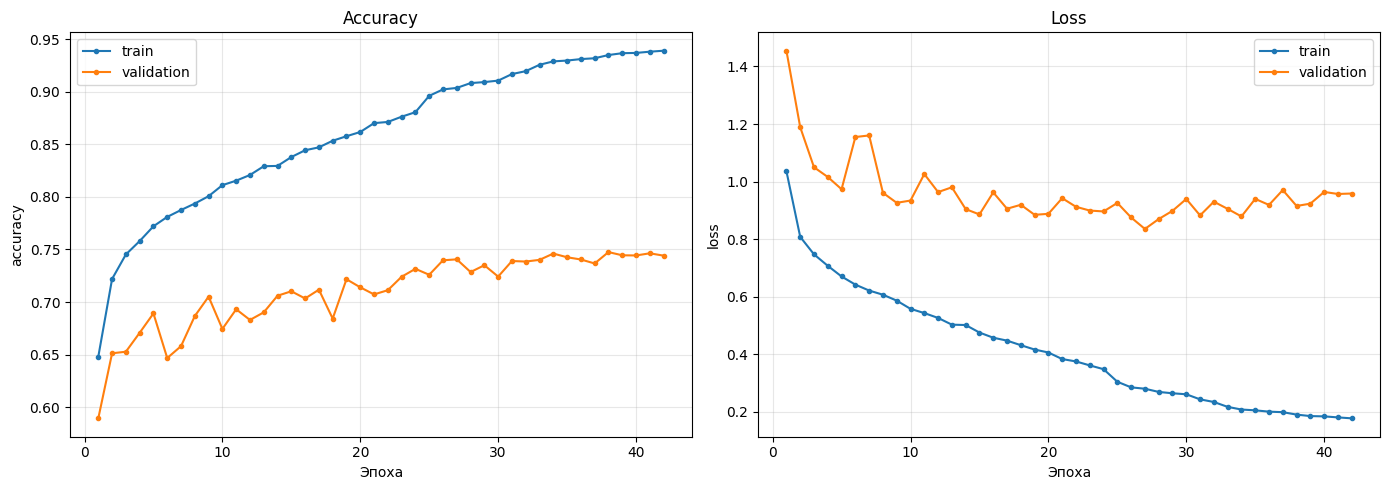

In [9]:
# ============================================================
# ШАГ 5. ГРАФИКИ ОБУЧЕНИЯ
# ============================================================
epochs_done = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_done, history.history['accuracy'],     label='train',      marker='.')
axes[0].plot(epochs_done, history.history['val_accuracy'], label='validation', marker='.')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('accuracy')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs_done, history.history['loss'],     label='train',      marker='.')
axes[1].plot(epochs_done, history.history['val_loss'], label='validation', marker='.')
axes[1].set_title('Loss'); axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('loss')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()


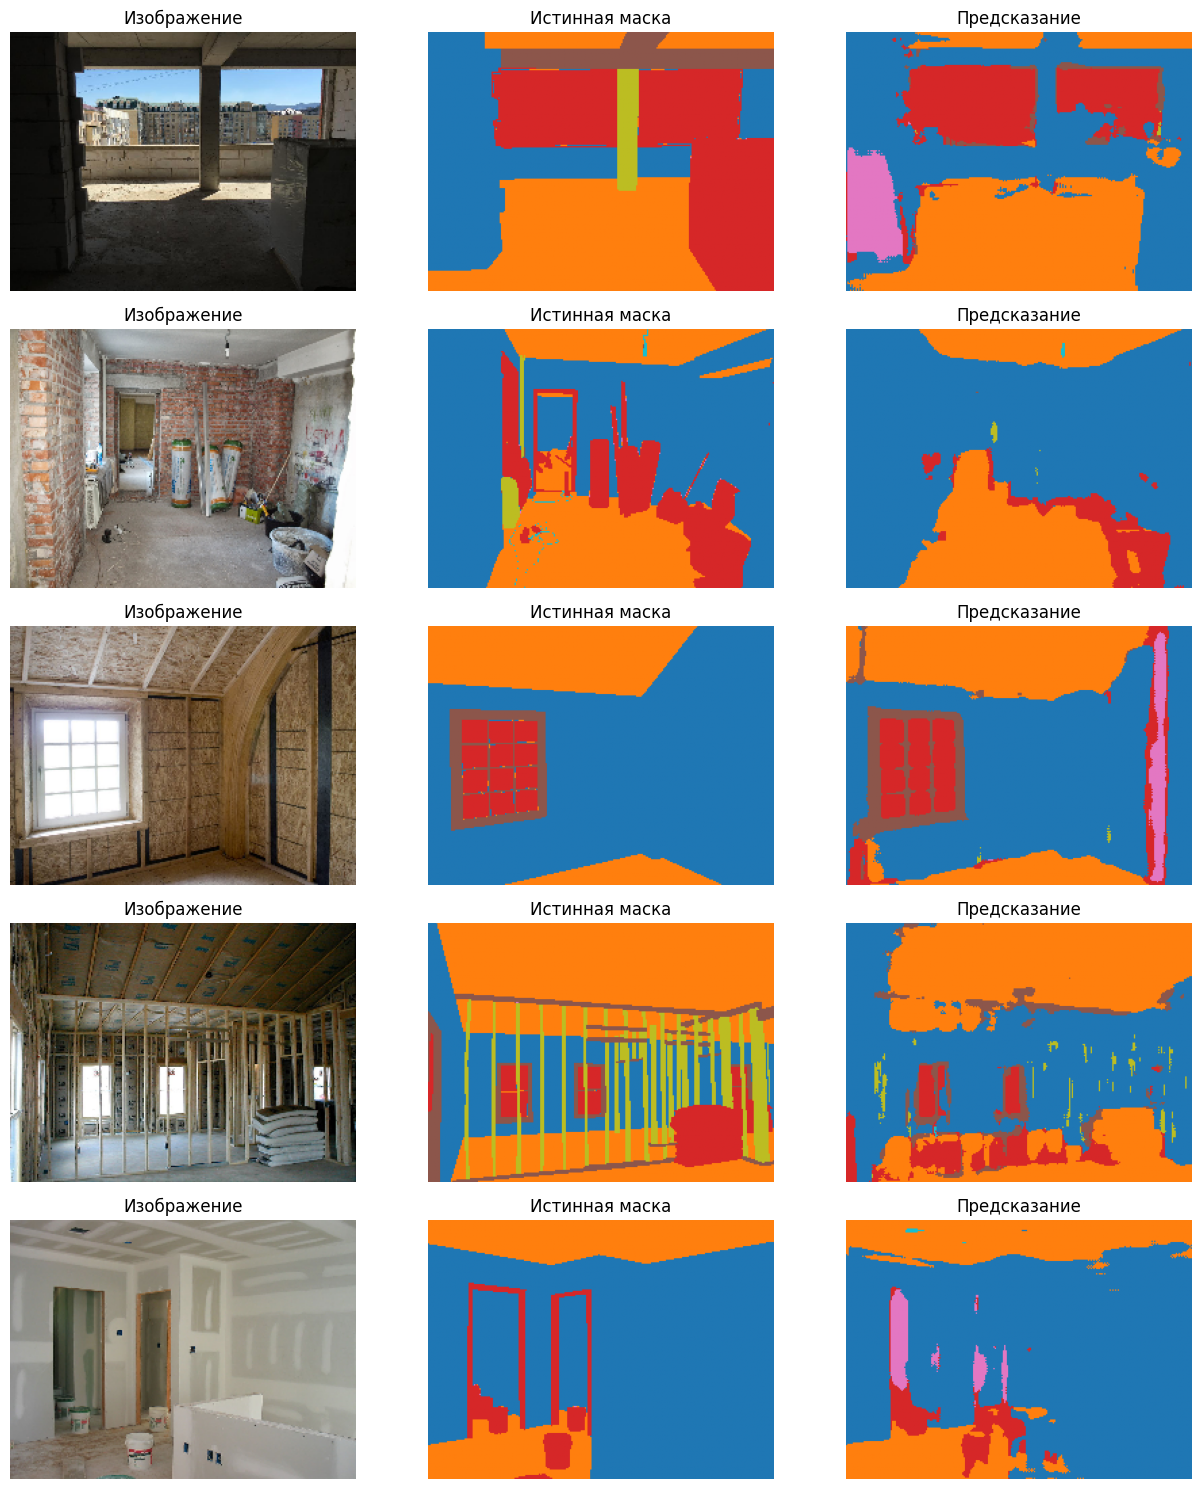


IoU по каждому классу на валидации:
  0 FLOOR       IoU = 0.7086
  1 CEILING     IoU = 0.6811
  2 WALL        IoU = 0.3326
  3 APERTURE    IoU = 0.2324
  4 SUPPORT     IoU = 0.2122
  5 INVENTORY   IoU = 0.0119
  6 OTHER       IoU = 0.0630

Mean IoU (по присутствующим классам): 0.3203


8805

In [10]:
# ============================================================
# ШАГ 6. ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ + IoU ПО КЛАССАМ
# ============================================================

# --- Несколько примеров с валидации ---
n_show = 5
idxs = np.random.choice(len(x_val), n_show, replace=False)
sample_x = x_val[idxs]
preds = unet.predict(sample_x, batch_size=BATCH_SIZE, verbose=0)
pred_classes = np.argmax(preds, axis=-1)
true_classes = y_val[idxs]

fig, axes = plt.subplots(n_show, 3, figsize=(13, 3.0 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(sample_x[i]);  axes[i, 0].set_title('Изображение');  axes[i, 0].axis('off')
    axes[i, 1].imshow(true_classes[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 1].set_title('Истинная маска'); axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_classes[i], cmap='tab10', vmin=0, vmax=NUM_CLASSES-1)
    axes[i, 2].set_title('Предсказание'); axes[i, 2].axis('off')
plt.tight_layout(); plt.show()

# --- IoU по каждому классу на полной валидации ---
print('\nIoU по каждому классу на валидации:')
batch = 16
val_pred_all = np.empty_like(y_val)
for s in range(0, len(x_val), batch):
    p = unet.predict(x_val[s:s+batch], verbose=0)
    val_pred_all[s:s+batch] = np.argmax(p, axis=-1).astype(np.int8)

ious = []
for c in range(NUM_CLASSES):
    inter = np.logical_and(y_val == c, val_pred_all == c).sum()
    union = np.logical_or (y_val == c, val_pred_all == c).sum()
    iou = inter / union if union > 0 else float('nan')
    ious.append(iou)
    print(f'  {c} {CLASS_NAMES[c]:<10s}  IoU = {iou:.4f}')

valid_ious = [v for v in ious if not np.isnan(v)]
print(f'\nMean IoU (по присутствующим классам): {np.mean(valid_ious):.4f}')

# Очистка
del preds, sample_x, val_pred_all
gc.collect()
